###### Mini Project 1
# **Seafood price monitoring (Yerevan-City.am)**

####**Emilya Karapetyan and Vivien Hasratyan**
-----------------------------------------------------

### Necessary imports libraries

In [ ]:
import pandas as pd
import re
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import chi2_contingency
from scipy.stats import pearsonr
from scipy.stats import shapiro
from scipy.stats import f_oneway

# Data Scraping

#### Importing the website which we scrap data from

In [ ]:
import requests
url = "https://yerevan-city.am/shop/products/27"
result = requests.get(url)
result

<Response [200]>

In [ ]:
print(result.status_code)

200


In [ ]:
result.content

b'<!doctype html>\r\n<html lang="en">\r\n<head>\r\n  <meta charset="utf-8">\r\n  <title>Yerevan City</title>\r\n  <base href="/">\r\n  <meta name="viewport" content="width=device-width, initial-scale=1.0, maximum-scale=1.0">\r\n  <meta name="theme-color" content="#df0026"/>\r\n  <link rel="icon" type="image/x-icon" href="favicon.ico">\r\n  <meta name="color-scheme" content="light dark">\r\n  <meta charset="utf-8">\r\n  <meta name="description" content="\xd4\xb5\xd6\x80\xd6\x87\xd5\xa1\xd5\xb6 \xd5\x8d\xd5\xab\xd5\xa9\xd5\xab\xd5\xb6 \xd5\xbd\xd5\xb8\xd6\x82\xd5\xba\xd5\xa5\xd6\x80\xd5\xb4\xd5\xa1\xd6\x80\xd5\xaf\xd5\xa5\xd5\xbf\xd5\xb6\xd5\xa5\xd6\x80\xd5\xab \xd5\xa1\xd5\xb4\xd5\xa5\xd5\xb6\xd5\xa1\xd5\xb4\xd5\xa5\xd5\xae \xd6\x81\xd5\xa1\xd5\xb6\xd6\x81\xd5\xb6 \xd5\xa7 \xd5\x80\xd5\xa1\xd5\xb5\xd5\xa1\xd5\xbd\xd5\xbf\xd5\xa1\xd5\xb6\xd5\xb8\xd6\x82\xd5\xb4\xd6\x89 \xd5\x84\xd5\xa5\xd6\x80 \xd5\xa1\xd5\xbc\xd6\x81\xd5\xa1\xd5\xb6\xd6\x81 \xd5\xad\xd5\xa1\xd5\xb6\xd5\xb8\xd6\x82\xd5\x

#### Do NOT run this code


In [ ]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.chrome.options import Options
from bs4 import BeautifulSoup
import time

url = "https://yerevan-city.am/shop/products/27"

chrome_options = Options()
chrome_options.add_argument("--headless")
chrome_options.add_argument("--disable-gpu")
chrome_options.add_argument("--no-sandbox")
chrome_options.add_argument("--disable-dev-shm-usage")

driver = webdriver.Chrome(options=chrome_options)

try:
    driver.set_page_load_timeout(60)
    driver.get(url)

    # Wait for the main product container
    WebDriverWait(driver, 30).until(
        EC.presence_of_element_located((By.CLASS_NAME, "P-list-products"))
    )

    #  Wait specifically for first product to appear
    WebDriverWait(driver, 30).until(
        EC.presence_of_element_located((By.CLASS_NAME, "P-product-description"))
    )

    # Optional: auto-scroll to load all products
    last_height = driver.execute_script("return document.body.scrollHeight")
    while True:
        driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
        time.sleep(2)  # wait for new items to load
        new_height = driver.execute_script("return document.body.scrollHeight")
        if new_height == last_height:
            break
        last_height = new_height

    # Now parse the fully loaded page
    soup = BeautifulSoup(driver.page_source, "html.parser")
    products = soup.select("div.P-product-description")

    if not products:
        print(" No products found even after scroll — site may render differently.")
    else:
        print(f" Found {len(products)} products!\n")
        for product in products:
            name_tag = product.select_one("p.P-text")
            price_tag = product.select_one("p.P-price span")

            product_name = name_tag.get_text(strip=True) if name_tag else "N/A"
            product_price = price_tag.get_text(strip=True) if price_tag else "N/A"

            print("Product Name:", product_name)
            print("Product Price:", product_price)
            print("-" * 40)

except Exception as e:
    print(" Error:", e)

finally:
    driver.quit()

#### Data Cleaning

##### Collecting data to raw_data.csv (do NOT run yet)

In [ ]:
import pandas as pd
import re

# 1. Collect scraped data into lists
product_names = []
product_prices = []

for product in products:
    name_tag = product.select_one("p.P-text")
    price_tag = product.select_one("p.P-price span")

    product_name = name_tag.get_text(strip=True) if name_tag else None
    product_price = price_tag.get_text(strip=True) if price_tag else None

    product_names.append(product_name)
    product_prices.append(product_price)

# 2. Create a DataFrame
df = pd.DataFrame({
    "Name": product_names,
    "Price": product_prices
})

df.to_csv("raw_data.csv", index=False)

##### You CAN run starting from here!




In [ ]:
data_csv = "https://drive.google.com/uc?export=download&id=1aQEil5Yp7XXxRzYW98NujOTx53iBXaWi"
df = pd.read_csv(data_csv)

# 3. Handle missing values
df.dropna(subset=["Name", "Price"], inplace=True)

# 4. Clean price column
def clean_price(x):
    # Remove spaces, non-breaking spaces, and currency symbols
    x = x.replace("\xa0", "").replace(" ", "")
    x = re.sub(r"[^\d,\.]", "", x)

    # Remove commas entirely (they are thousands separators)
    x = x.replace(",", "")

    try:
        return float(x)
    except ValueError:
        return None

df["Price"] = df["Price"].apply(clean_price)

# 5. Handle outliers (optional)
mean_price = df["Price"].mean()
std_price = df["Price"].std()
df["Outlier"] = ((df["Price"] - mean_price).abs() > 3 * std_price)

# 6. Normalization
df["Price_Normalized"] = (df["Price"] - df["Price"].min()) / (df["Price"].max() - df["Price"].min())

# 7. Inspect cleaned data
print(df.head(10))


                                               Name    Price  Outlier  \
0     Ծովախեցգետնի վերջույթ.եփ-սառ.Կամչատ.4Իքսէլ կգ  15900.0    False   
1      Ձկնկիթ թառափի «Կայտառ» պրեմիում, սև ա/տ 60գր  20990.0     True   
2         Ձկնկիթ թառափի «Չ.Ձոր» Դիմարե, սև թ/տ 50գր  18200.0     True   
3           Ձկնկիթ կետայի «Լունսկոե մորե» ա/տ 200գր  16490.0    False   
4       Ձկնկիթ թառափի «Կայտառ» դասական, սև թ/տ 50գր  14300.0    False   
5  Ծովախեցգետին թագավորական մաքրած 41/50 «Վիչի» 1կգ  11990.0    False   
6             Թունայի ֆիլե սառը ապխտած «Օկեանոս» կգ  11150.0    False   
7        Պահածոյացված անչոուս «Ագոստինո Ռեկա» 540գր  10090.0    False   
8       Ծովախեցգետին 21/25 թագ. սառ. առանց գլուխ կգ   9650.0    False   
9                         Թունայի սթեյք սառեցված կգ   9350.0    False   

   Price_Normalized  
0          0.727807  
1          1.000000  
2          0.850802  
3          0.759358  
4          0.642246  
5          0.518717  
6          0.473797  
7          0.417112 

In [ ]:
df.to_csv("cleaned_data.csv", index=False, encoding="utf-8-sig")
print(" Data saved to cleaned_data.csv")

 Data saved to cleaned_data.csv



# Data Preprocessing


### Export the dataset from Drive for data preprocessing

In [ ]:
import pandas as pd
data_csv = "https://drive.google.com/uc?export=download&id=1cdZqVZXCgksJMPgmv4ansQOYxySPuOsc"
df = pd.read_csv(data_csv)
df

,Name,Price,Outlier,Price_Normalized
0,Ծովախեցգետնի վերջույթ.եփ-սառ.Կամչատ.4Իքսէլ կգ,15900.0,False,0.727807
1,"Ձկնկիթ թառափի «Կայտառ» պրեմիում, սև ա/տ 60գր",20990.0,True,1.000000
2,"Ձկնկիթ թառափի «Չ.Ձոր» Դիմարե, սև թ/տ 50գր",18200.0,True,0.850802
3,Ձկնկիթ կետայի «Լունսկոե մորե» ա/տ 200գր,16490.0,False,0.759358
4,"Ձկնկիթ թառափի «Կայտառ» դասական, սև թ/տ 50գր",14300.0,False,0.642246
...,...,...,...,...
81,Իշխան թույլ աղադրած «Այս Բերգ» կտրատած 100գր,2380.0,False,0.004813
82,Իշխանի ֆիլե սառը ապխտած «Այս Բերգ» կտրատած 100գր,2380.0,False,0.004813
83,"Իշխանի ֆիլե ապխտած «Չ.Ձոր» Դիմարե, կտրատած 100գր",2470.0,False,0.009626
84,Սկումբրիա ապխտած «Օուշն Ֆիշ» հտ,2290.0,False,0.000000


### 1. Extract weight of a product

In [ ]:
#Extracts weight from the product name: handles grams, kilograms, or defaults to 1kg; converts all to grams
df["Weight_g"] = df["Name"].apply(lambda x: (
    float(re.search(r'(\d+(?:\.\d+)?)\s*գր', x).group(1)) if re.search(r'(\d+(?:\.\d+)?)\s*գր', x)
    else float(re.search(r'(\d+(?:\.\d+)?)\s*կգ', x).group(1))*1000 if re.search(r'(\d+(?:\.\d+)?)\s*կգ', x) #converts the weight into grams
    else 1000 if re.search(r'\bկգ\b', x)
    else None
))
df

,Name,Price,Outlier,Price_Normalized,Weight_g
0,Ծովախեցգետնի վերջույթ.եփ-սառ.Կամչատ.4Իքսէլ կգ,15900.0,False,0.727807,1000.0
1,"Ձկնկիթ թառափի «Կայտառ» պրեմիում, սև ա/տ 60գր",20990.0,True,1.000000,60.0
2,"Ձկնկիթ թառափի «Չ.Ձոր» Դիմարե, սև թ/տ 50գր",18200.0,True,0.850802,50.0
3,Ձկնկիթ կետայի «Լունսկոե մորե» ա/տ 200գր,16490.0,False,0.759358,200.0
4,"Ձկնկիթ թառափի «Կայտառ» դասական, սև թ/տ 50գր",14300.0,False,0.642246,50.0
...,...,...,...,...,...
81,Իշխան թույլ աղադրած «Այս Բերգ» կտրատած 100գր,2380.0,False,0.004813,100.0
82,Իշխանի ֆիլե սառը ապխտած «Այս Բերգ» կտրատած 100գր,2380.0,False,0.004813,100.0
83,"Իշխանի ֆիլե ապխտած «Չ.Ձոր» Դիմարե, կտրատած 100գր",2470.0,False,0.009626,100.0
84,Սկումբրիա ապխտած «Օուշն Ֆիշ» հտ,2290.0,False,0.000000,NaN


### 2. Extract brand name of the product

In [ ]:
#Extracts brand from quotes; if no brand is found, assigns "Yerevan City"
df["Brand"] = df["Name"].apply(lambda x: re.search(r'«([^»]+)»', x).group(1) if re.search(r'«([^»]+)»', x) else "Yerevan City")
df

,Name,Price,Outlier,Price_Normalized,Weight_g,Brand
0,Ծովախեցգետնի վերջույթ.եփ-սառ.Կամչատ.4Իքսէլ կգ,15900.0,False,0.727807,1000.0,Yerevan City
1,"Ձկնկիթ թառափի «Կայտառ» պրեմիում, սև ա/տ 60գր",20990.0,True,1.000000,60.0,Կայտառ
2,"Ձկնկիթ թառափի «Չ.Ձոր» Դիմարե, սև թ/տ 50գր",18200.0,True,0.850802,50.0,Չ.Ձոր
3,Ձկնկիթ կետայի «Լունսկոե մորե» ա/տ 200գր,16490.0,False,0.759358,200.0,Լունսկոե մորե
4,"Ձկնկիթ թառափի «Կայտառ» դասական, սև թ/տ 50գր",14300.0,False,0.642246,50.0,Կայտառ
...,...,...,...,...,...,...
81,Իշխան թույլ աղադրած «Այս Բերգ» կտրատած 100գր,2380.0,False,0.004813,100.0,Այս Բերգ
82,Իշխանի ֆիլե սառը ապխտած «Այս Բերգ» կտրատած 100գր,2380.0,False,0.004813,100.0,Այս Բերգ
83,"Իշխանի ֆիլե ապխտած «Չ.Ձոր» Դիմարե, կտրատած 100գր",2470.0,False,0.009626,100.0,Չ.Ձոր
84,Սկումբրիա ապխտած «Օուշն Ֆիշ» հտ,2290.0,False,0.000000,NaN,Օուշն Ֆիշ


### 3. Fill missing values by Group Median

---
If Weight_g missing → fill with median of that Brand

If Price missing → fill with median of that Brand


In [ ]:
df["Weight_g"] = df.groupby("Brand")["Weight_g"].transform(
    lambda x: x.fillna(x.median())
)

df["Price"] = df.groupby("Brand")["Price"].transform(
    lambda x: x.fillna(x.median())
)


If a brand has only 1–2 rows and still NaN then fill with global median

In [ ]:
df["Weight_g"] = df["Weight_g"].fillna(df["Weight_g"].median())
df["Price"] = df["Price"].fillna(df["Price"].median())


### 4. Checking if Price and Weight Are Digits

In [ ]:
df_clean = df.copy()

#contains non-numeric values ---
df_clean["Price_is_digit"] = df_clean["Price"].astype(str).str.replace(".", "", regex=False).str.isdigit()

#Price is NOT a number
non_numeric_price = df_clean[~df_clean["Price_is_digit"]]
print("Non-numeric Price values:\n", non_numeric_price)

#Convert Price to numeric (force errors to NaN)
df_clean["Price"] = pd.to_numeric(df_clean["Price"], errors="coerce")


Non-numeric Price values:
 Empty DataFrame
Columns: [Name, Price, Outlier, Price_Normalized, Weight_g, Brand, Price_is_digit]
Index: []


### 5. Calculating price per gram

In [ ]:
#Calculate the price per gram
df["Price_per_gram"] = df["Price"] / df["Weight_g"]
df

,Name,Price,Outlier,Price_Normalized,Weight_g,Brand,Price_per_gram
0,Ծովախեցգետնի վերջույթ.եփ-սառ.Կամչատ.4Իքսէլ կգ,15900.0,False,0.727807,1000.0,Yerevan City,15.900000
1,"Ձկնկիթ թառափի «Կայտառ» պրեմիում, սև ա/տ 60գր",20990.0,True,1.000000,60.0,Կայտառ,349.833333
2,"Ձկնկիթ թառափի «Չ.Ձոր» Դիմարե, սև թ/տ 50գր",18200.0,True,0.850802,50.0,Չ.Ձոր,364.000000
3,Ձկնկիթ կետայի «Լունսկոե մորե» ա/տ 200գր,16490.0,False,0.759358,200.0,Լունսկոե մորե,82.450000
4,"Ձկնկիթ թառափի «Կայտառ» դասական, սև թ/տ 50գր",14300.0,False,0.642246,50.0,Կայտառ,286.000000
...,...,...,...,...,...,...,...
81,Իշխան թույլ աղադրած «Այս Բերգ» կտրատած 100գր,2380.0,False,0.004813,100.0,Այս Բերգ,23.800000
82,Իշխանի ֆիլե սառը ապխտած «Այս Բերգ» կտրատած 100գր,2380.0,False,0.004813,100.0,Այս Բերգ,23.800000
83,"Իշխանի ֆիլե ապխտած «Չ.Ձոր» Դիմարե, կտրատած 100գր",2470.0,False,0.009626,100.0,Չ.Ձոր,24.700000
84,Սկումբրիա ապխտած «Օուշն Ֆիշ» հտ,2290.0,False,0.000000,1000.0,Օուշն Ֆիշ,2.290000


# Data Analysis


### 1. Descriptive Statistics

In [ ]:
summary = df[['Price', 'Weight_g', 'Price_per_gram']].describe().T
summary['median'] = df[['Price', 'Weight_g', 'Price_per_gram']].median()
summary['mode'] = df[['Price', 'Weight_g', 'Price_per_gram']].mode().iloc[0]
summary['skewness'] = df[['Price', 'Weight_g', 'Price_per_gram']].skew()

print(summary)


                count         mean           std         min        25%  \
Price            86.0  5891.744186   3660.522686  2290.00000  3455.0000   
Weight_g         86.0  3585.523256  22369.578029    30.00000   200.0000   
Price_per_gram   86.0    28.032298     67.582079     0.03225     5.9225   

                       50%          75%       max      median     mode  \
Price           4670.00000  7135.000000   20990.0  4670.00000  2990.00   
Weight_g         500.00000  1000.000000  200000.0   500.00000  1000.00   
Price_per_gram     9.13381    19.971296     364.0     9.13381    14.95   

                skewness  
Price           1.974357  
Weight_g        8.344180  
Price_per_gram  4.248945  


### 2. Distribution Analysis

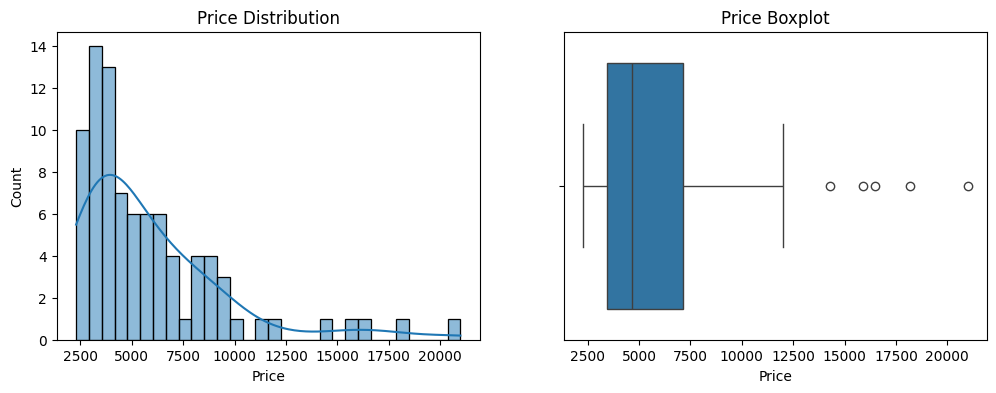

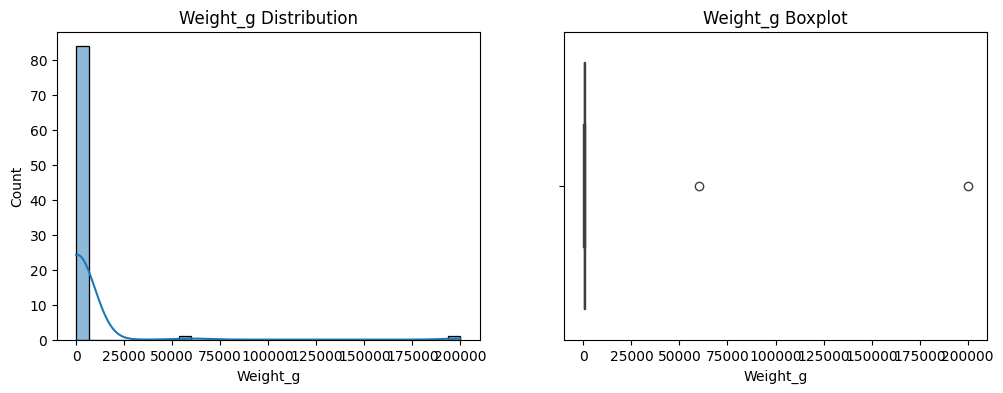

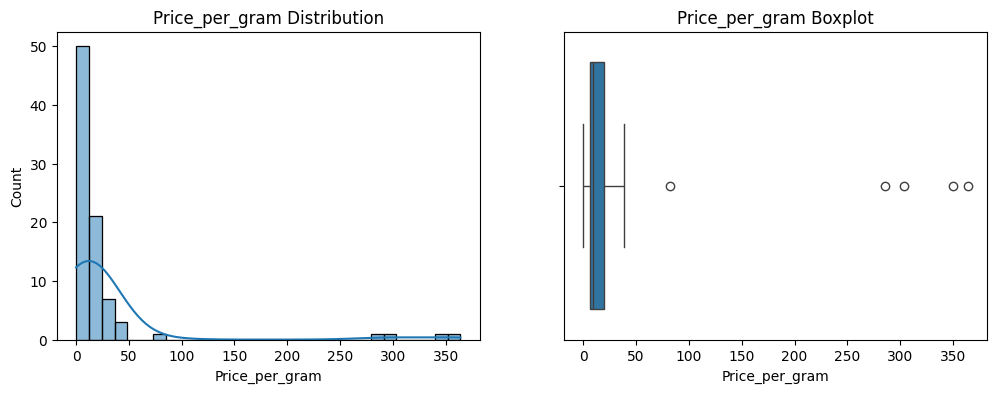

In [ ]:
cols = ['Price', 'Weight_g', 'Price_per_gram']

for col in cols:
    plt.figure(figsize=(12,4))

    # Histogram + KDE
    plt.subplot(1,2,1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"{col} Distribution")

    # Boxplot
    plt.subplot(1,2,2)
    sns.boxplot(x=df[col])
    plt.title(f"{col} Boxplot")

    plt.show()


### 3. Correlation Analysis

In [ ]:
numerical_cols = ['Price', 'Weight_g', 'Price_per_gram']

pearson_corr = df[numerical_cols].corr(method='pearson')      # linear
spearman_corr = df[numerical_cols].corr(method='spearman')    # monotonic
kendall_corr = df[numerical_cols].corr(method='kendall')      # rank-based

print("\nPearson Correlation:\n", pearson_corr)
print("\nSpearman Correlation:\n", spearman_corr)
print("\nKendall Correlation:\n", kendall_corr)



Pearson Correlation:
                    Price  Weight_g  Price_per_gram
Price           1.000000  0.007671        0.643793
Weight_g        0.007671  1.000000       -0.063324
Price_per_gram  0.643793 -0.063324        1.000000

Spearman Correlation:
                    Price  Weight_g  Price_per_gram
Price           1.000000  0.227750        0.212634
Weight_g        0.227750  1.000000       -0.861471
Price_per_gram  0.212634 -0.861471        1.000000

Kendall Correlation:
                    Price  Weight_g  Price_per_gram
Price           1.000000  0.185141        0.183693
Weight_g        0.185141  1.000000       -0.712110
Price_per_gram  0.183693 -0.712110        1.000000


# Hypothesis Testing

### 1. ANOVA — Do different brands have different Price_per_gram?

---


H₀: All brands have the same average price per gram


H₁: At least one brand has a different average price per gram

In [ ]:
groups = [df[df["Brand"] == b]["Price_per_gram"].dropna()
          for b in df["Brand"].unique()]

f_stat, p_val = f_oneway(*groups)
print(p_val)


4.2000526776164424e-07


it's ≈0 so we reject the null hypothesis.

### 2. Correlation test — Does weight affect the price?

---
H₀: Weight has no relationship with Price


H₁: Weight is significantly correlated with Price


In [ ]:
corr, pval = pearsonr(df["Weight_g"], df["Price"])

print(corr, pval)


0.007670728564414547 0.9441176480376681


Correlation coefficient = -0.0209, This is almost zero, meaning no real relationship between weight and price.

p-value = 0.804 > 0.05, we do not reject H₀.

### 3. Chi-square test — Are outliers associated with specific brands?

---
H₀: Brand and Outlier status are independent

H₁: Outliers depend on the brand


In [ ]:
table = pd.crosstab(df["Brand"], df["Outlier"])
chi2_contingency(table)


Chi2ContingencyResult(statistic=np.float64(21.43174603174603), pvalue=np.float64(0.16250537955968805), dof=16, expected_freq=array([[20.51162791,  0.48837209],
       [ 4.88372093,  0.11627907],
       [ 0.97674419,  0.02325581],
       [18.55813953,  0.44186047],
       [ 2.93023256,  0.06976744],
       [ 0.97674419,  0.02325581],
       [ 0.97674419,  0.02325581],
       [ 4.88372093,  0.11627907],
       [ 0.97674419,  0.02325581],
       [ 0.97674419,  0.02325581],
       [ 2.93023256,  0.06976744],
       [ 1.95348837,  0.04651163],
       [ 0.97674419,  0.02325581],
       [ 7.81395349,  0.18604651],
       [ 7.81395349,  0.18604651],
       [ 2.93023256,  0.06976744],
       [ 2.93023256,  0.06976744]]))

p-value = 7.86e-05< 0.05, so we reject H₀.

### 4. Normality tests

---
H₀: The distribution is normal

H₁: The distribution is not normal


In [ ]:
from scipy.stats import shapiro
import pandas as pd # Import pandas just in case, though df should be defined
# Assuming 'df' is your DataFrame from the previous steps
numerical_cols = ['Price', 'Weight_g', 'Price_per_gram']

print("--- Shapiro-Wilk Normality Test ---")
print("H₀: The distribution is normal")
print("H₁: The distribution is not normal\n")

for col in numerical_cols:
    # Run Shapiro-Wilk test on the column data
    # Note: df[col] is the 'data' here
    stat, pval = shapiro(df[col])

    print(f"--- {col} ---")
    print(f"Shapiro statistic: {stat:.4f}")
    print(f"p-value: {pval:.5f}")


    if pval < 0.05:
        print("Conclusion: Reject H₀. The data is NOT normally distributed.")
    else:
        print("Conclusion: Fail to Reject H₀. The data is normally distributed (or close enough).")

--- Shapiro-Wilk Normality Test ---
H₀: The distribution is normal
H₁: The distribution is not normal

--- Price ---
Shapiro statistic: 0.7975
p-value: 0.00000
Conclusion: Reject H₀. The data is NOT normally distributed.
--- Weight_g ---
Shapiro statistic: 0.1287
p-value: 0.00000
Conclusion: Reject H₀. The data is NOT normally distributed.
--- Price_per_gram ---
Shapiro statistic: 0.3472
p-value: 0.00000
Conclusion: Reject H₀. The data is NOT normally distributed.


# Data Visualization

### 1. Price vs. Weight_g

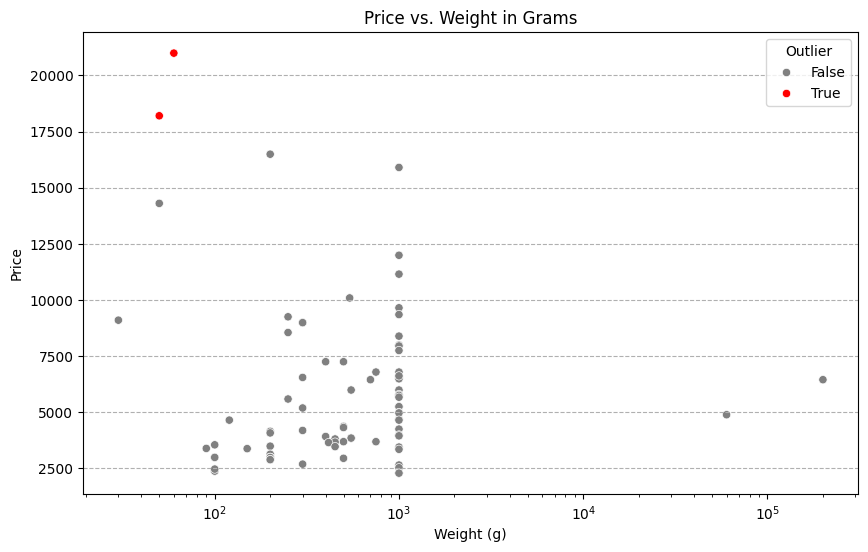

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x="Weight_g", y="Price", data=df, hue="Outlier", palette=["gray", "red"])
plt.title("Price vs. Weight in Grams")
plt.xlabel("Weight (g)")
plt.ylabel("Price")
plt.xscale('log') # log scale for better visual spread of Weight
plt.grid(axis='y', linestyle='--')
plt.show()

### 2. Histograms and Density Plots: Distribution of Price_per_gram

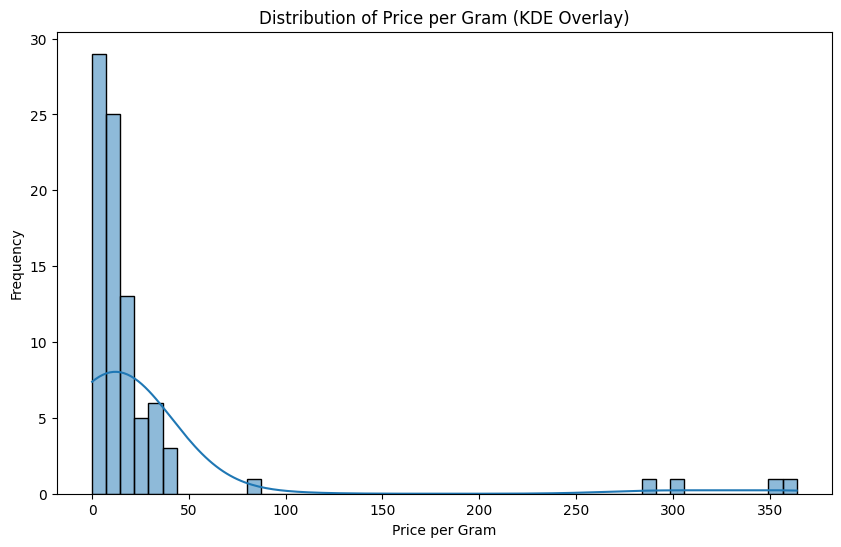

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df["Price_per_gram"].dropna(), bins=50, kde=True)
plt.title("Distribution of Price per Gram (KDE Overlay)")
plt.xlabel("Price per Gram")
plt.ylabel("Frequency")
plt.show()

### 3. Heat Maps: Correlation Matrix

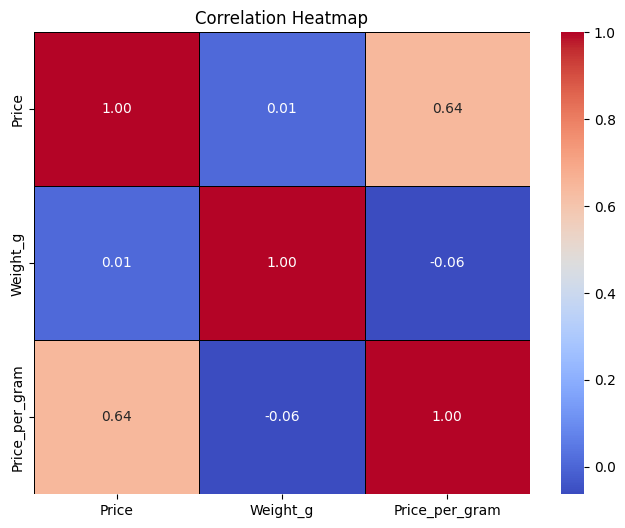

In [ ]:
# Select numerical columns and calculate correlation matrix
corr_matrix = df[["Price", "Weight_g", "Price_per_gram"]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, linecolor='black')
plt.title("Correlation Heatmap")
plt.show()

### 4. Pairplot (Scatterplot Matrix)

---

Shows pairwise relationships

Identifies patterns, clusters, non-linear relationships

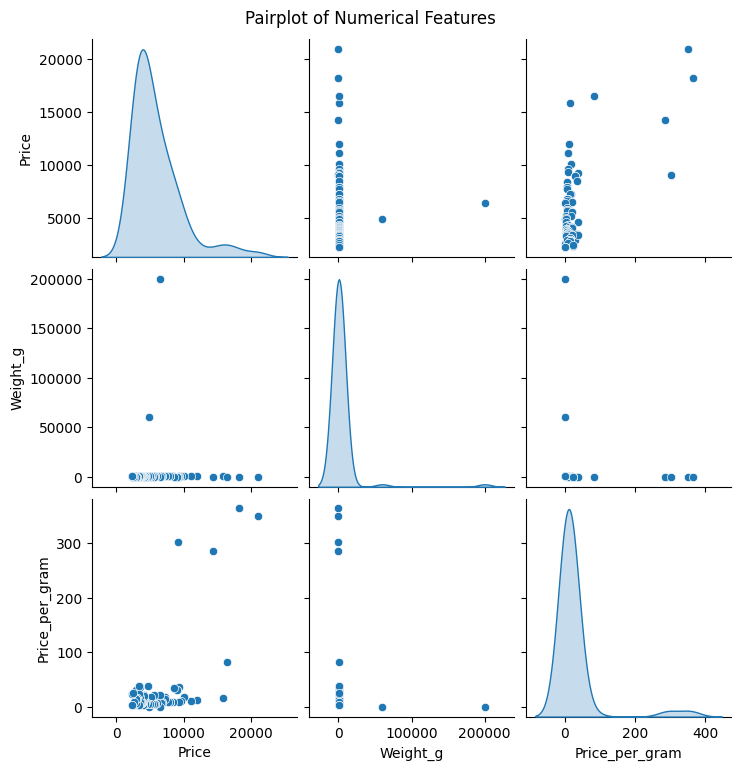

In [ ]:
sns.pairplot(df[["Price", "Weight_g", "Price_per_gram"]], diag_kind="kde")
plt.suptitle("Pairplot of Numerical Features", y=1.02)
plt.show()


### 5. Bar Plots: Distribution of Top 10 Brands

/tmp/ipython-input-814619153.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_brands.index, y=top_10_brands.values, palette="viridis")


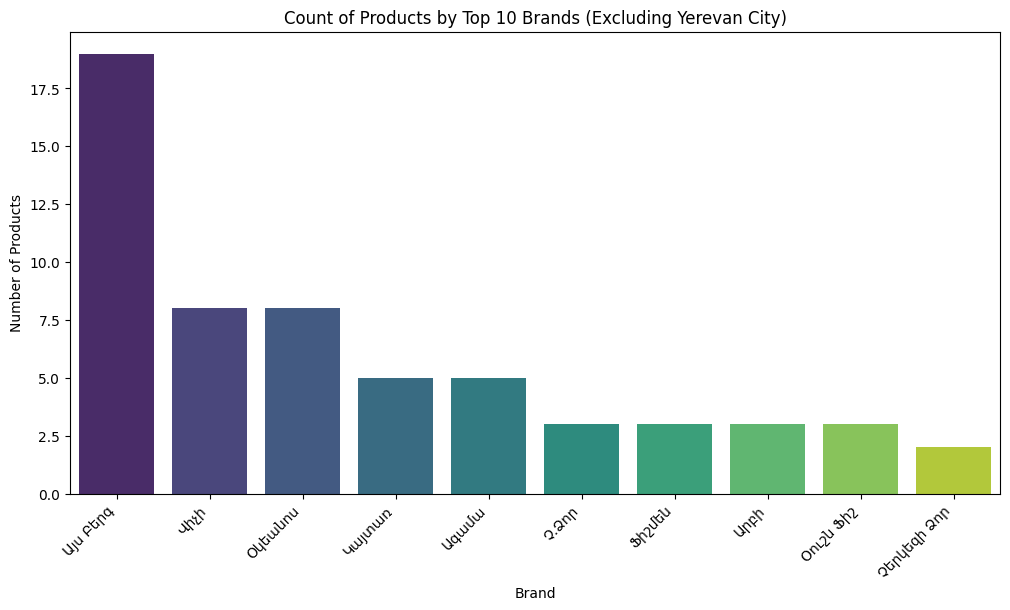

In [ ]:
# Remove Yerevan City from brand list (since it is the replacement for missing brand values)
df_no_yc = df[df["Brand"] != "Yerevan City"]

# Top 10 remaining brands
top_10_brands = df_no_yc["Brand"].value_counts().nlargest(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_brands.index, y=top_10_brands.values, palette="viridis")
plt.title("Count of Products by Top 10 Brands (Excluding Yerevan City)")
plt.xlabel("Brand")
plt.ylabel("Number of Products")
plt.xticks(rotation=45, ha='right')
plt.show()


### 6. Quantity of product at a given price


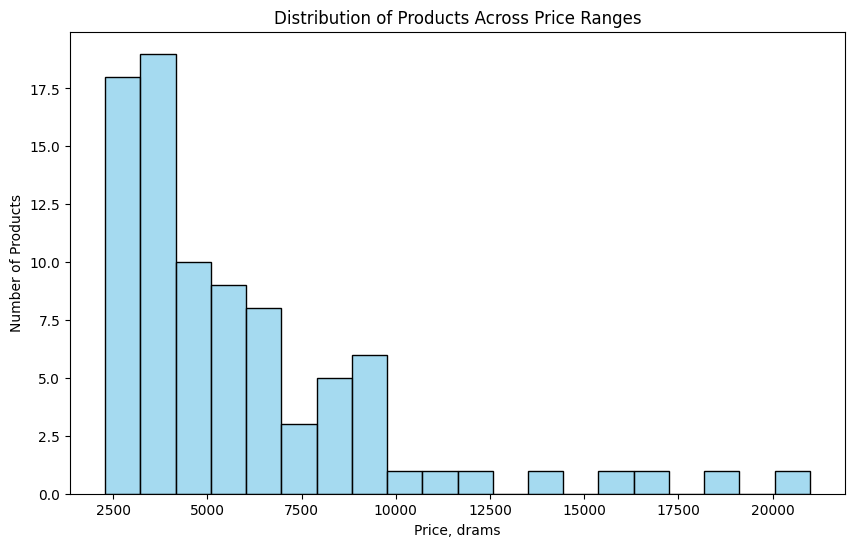

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df["Price"], bins=20, kde=False, color="skyblue")
plt.xlabel("Price, drams")
plt.ylabel("Number of Products")
plt.title("Distribution of Products Across Price Ranges")
plt.show()


### 7. Average price per brand

/tmp/ipython-input-2254028597.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


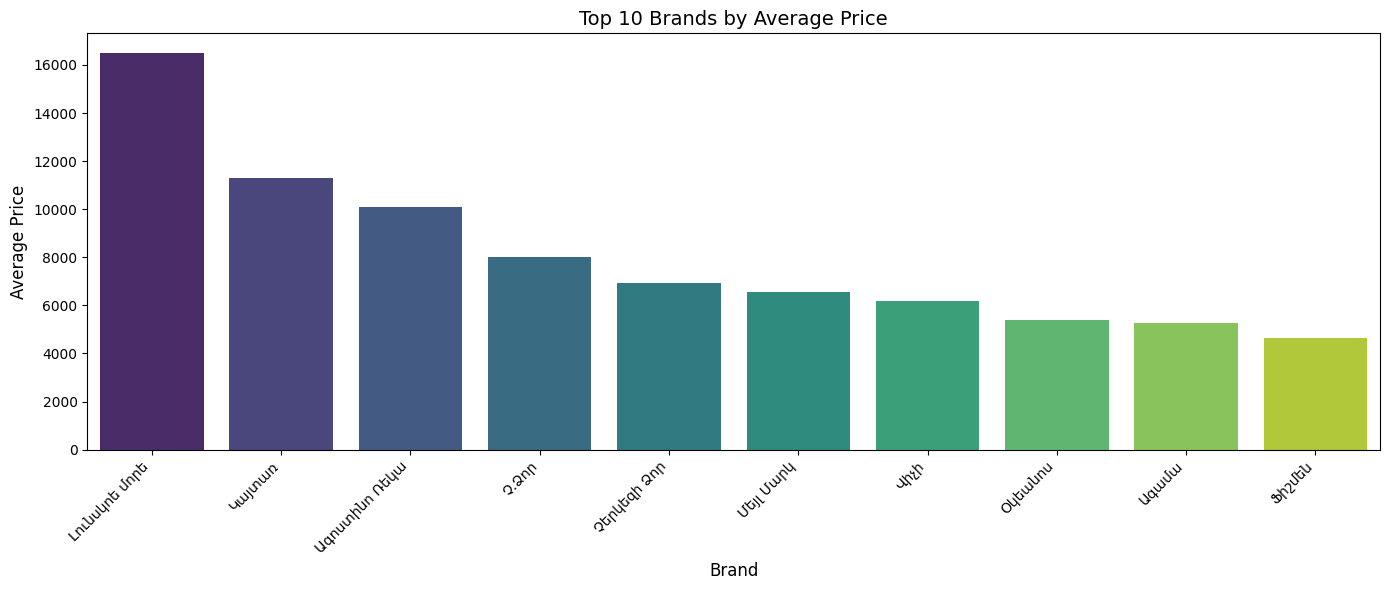

In [ ]:
# Compute average price per brand
brand_avg = df.groupby('Brand')['Price'].mean().sort_values(ascending=False)

# Remove 'Yerevan City' if it exists
brand_avg_filtered = brand_avg.drop("Yerevan City", errors="ignore")

# Plot top 10 brands
plt.figure(figsize=(14, 6))
sns.barplot(
    x=brand_avg_filtered.index[:10],
    y=brand_avg_filtered.values[:10],
    palette="viridis"
)

plt.title("Top 10 Brands by Average Price", fontsize=14)
plt.xlabel("Brand", fontsize=12)
plt.ylabel("Average Price", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()
plt.show()
